In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..', 'lime_ndt')))
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..')))

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from lime_ndt.lime_tabular import LimeTabularExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper

# Charger le dataset diabetes
housing = fetch_california_housing()
X = housing.data
y = housing.target  # Cible de régression

# Séparer en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Entraîner le modèle global Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Fonction de prédiction globale utilisant le Random Forest
def predict_fn(X):
    return rf.predict(X)

# Créer l'explainer LIME
explainer = LimeTabularExplainer(
    X_train,
    feature_names=housing.feature_names,
    class_names=None,
    discretize_continuous=True,
    mode='regression',    
)

# Créer le modèle local NDT
model_regressor = NDTRegressorWrapper(D=X_train.shape[1])

# Expliquer une instance
exp = explainer.explain_instance(
    X_test[1],
    predict_fn,
    num_features=8,
    model_regressor=model_regressor
)

print("Explication locale (feature, poids):")
print(exp.as_list())

mean_leaf_values shape: (32, 1, 1)
self.L: 32 self.C: 1
mean_leaf_values shape after squeeze: (32, 1)



c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Explication locale (feature, poids):
[('MedInc <= 2.57', -8.859075213759384), ('34.27 < Latitude <= 37.72', -3.3373061215743878), ('AveBedrms > 1.10', 1.2860317417653147), ('4.45 < AveRooms <= 5.23', -0.656295124826106), ('-121.80 < Longitude <= -118.51', 0.4175970074965396), ('1167.00 < Population <= 1727.00', -0.09483977595359283), ('29.00 < HouseAge <= 37.00', -0.03339287930068924), ('2.43 < AveOccup <= 2.82', -0.0006468965066259713)]


In [3]:
from lime.lime_tabular import LimeTabularExplainer

# Créer l'explainer LIME officiel
explainer_lime = LimeTabularExplainer(
    X_train,
    feature_names=housing.feature_names,
    class_names=None,
    discretize_continuous=True,
    mode='regression',
)

# Expliquer une instance avec le modèle local Ridge par défaut de LIME
exp_ridge = explainer_lime.explain_instance(
    X_test[1],
    predict_fn,
    num_features=8
)

print("\nExplication locale avec Ridge (LIME officiel) (feature, poids):")
print(exp_ridge.as_list())


Explication locale avec Ridge (LIME officiel) (feature, poids):
[('MedInc <= 2.57', -0.8206733836468061), ('34.27 < Latitude <= 37.72', -0.27080853851334546), ('-121.80 < Longitude <= -118.51', 0.12528212443267603), ('AveBedrms > 1.10', 0.12098512394913265), ('4.45 < AveRooms <= 5.23', -0.09835539724315472), ('29.00 < HouseAge <= 37.00', 0.06536633134252441), ('1167.00 < Population <= 1727.00', 0.013193213354506943), ('2.43 < AveOccup <= 2.82', -0.0007352584100838918)]


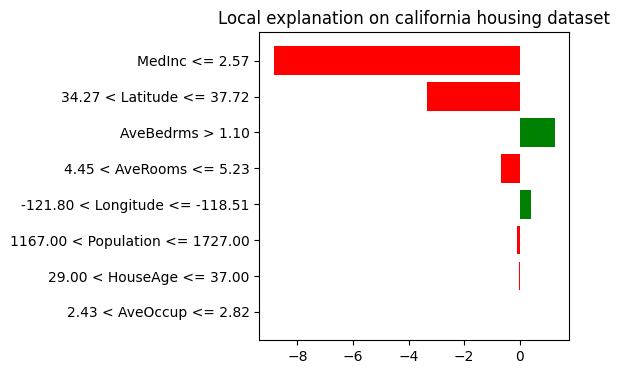

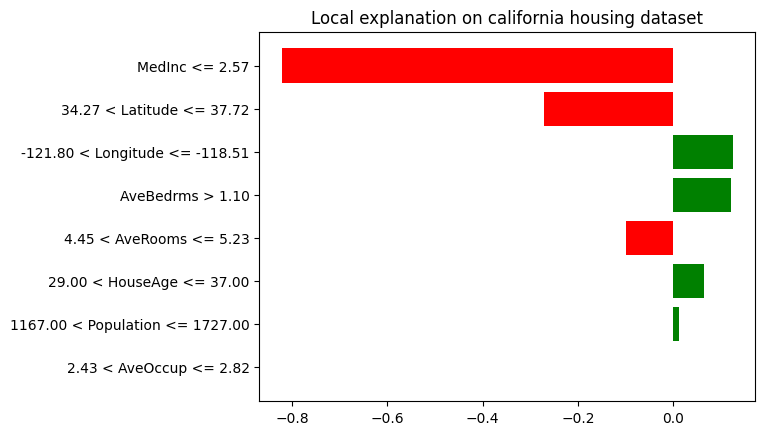

In [5]:
import matplotlib.pyplot as plt

fig = exp.as_pyplot_figure()
fig.axes[0].set_title("Local explanation on california housing dataset")
plt.show()

fig_ridge = exp_ridge.as_pyplot_figure()
fig_ridge.axes[0].set_title("Local explanation on california housing dataset")
plt.show()